# Kaggle Heart Disease Cleveland

url: https://www.kaggle.com/datasets/ritwikb3/heart-disease-cleveland/data

## Related Notebook (Jupyter)
### HeartDisease-EDA and prediction - 91.8% accuracy

url: https://www.kaggle.com/code/codealpha07/heartdisease-eda-and-prediction-91-8-accuracy

In [ ]:
! pip install pandas numpy matplotlib seaborn scikit-learn plotly yellowbrick xgboost nbformat lightgbm

In [ ]:
! pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor, BaggingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report ,mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')


<h2>Loading the Dataset</h2>

In [5]:
df=pd.read_csv('Heart_disease_cleveland_new.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [6]:
df.shape

(303, 14)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


<h3>Checking for any missing values</h3>

Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


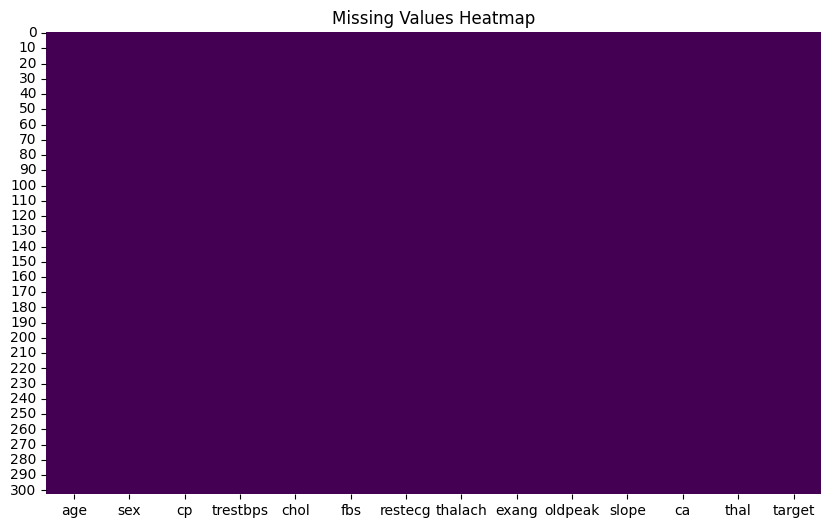

In [9]:
missing_vals = df.isnull().sum()
missing_pct = (missing_vals / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_vals, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Values'] > 0])

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [10]:
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate records: {duplicate_count}")


Number of duplicate records: 0


<h3>Plotting the pair plot</h3>

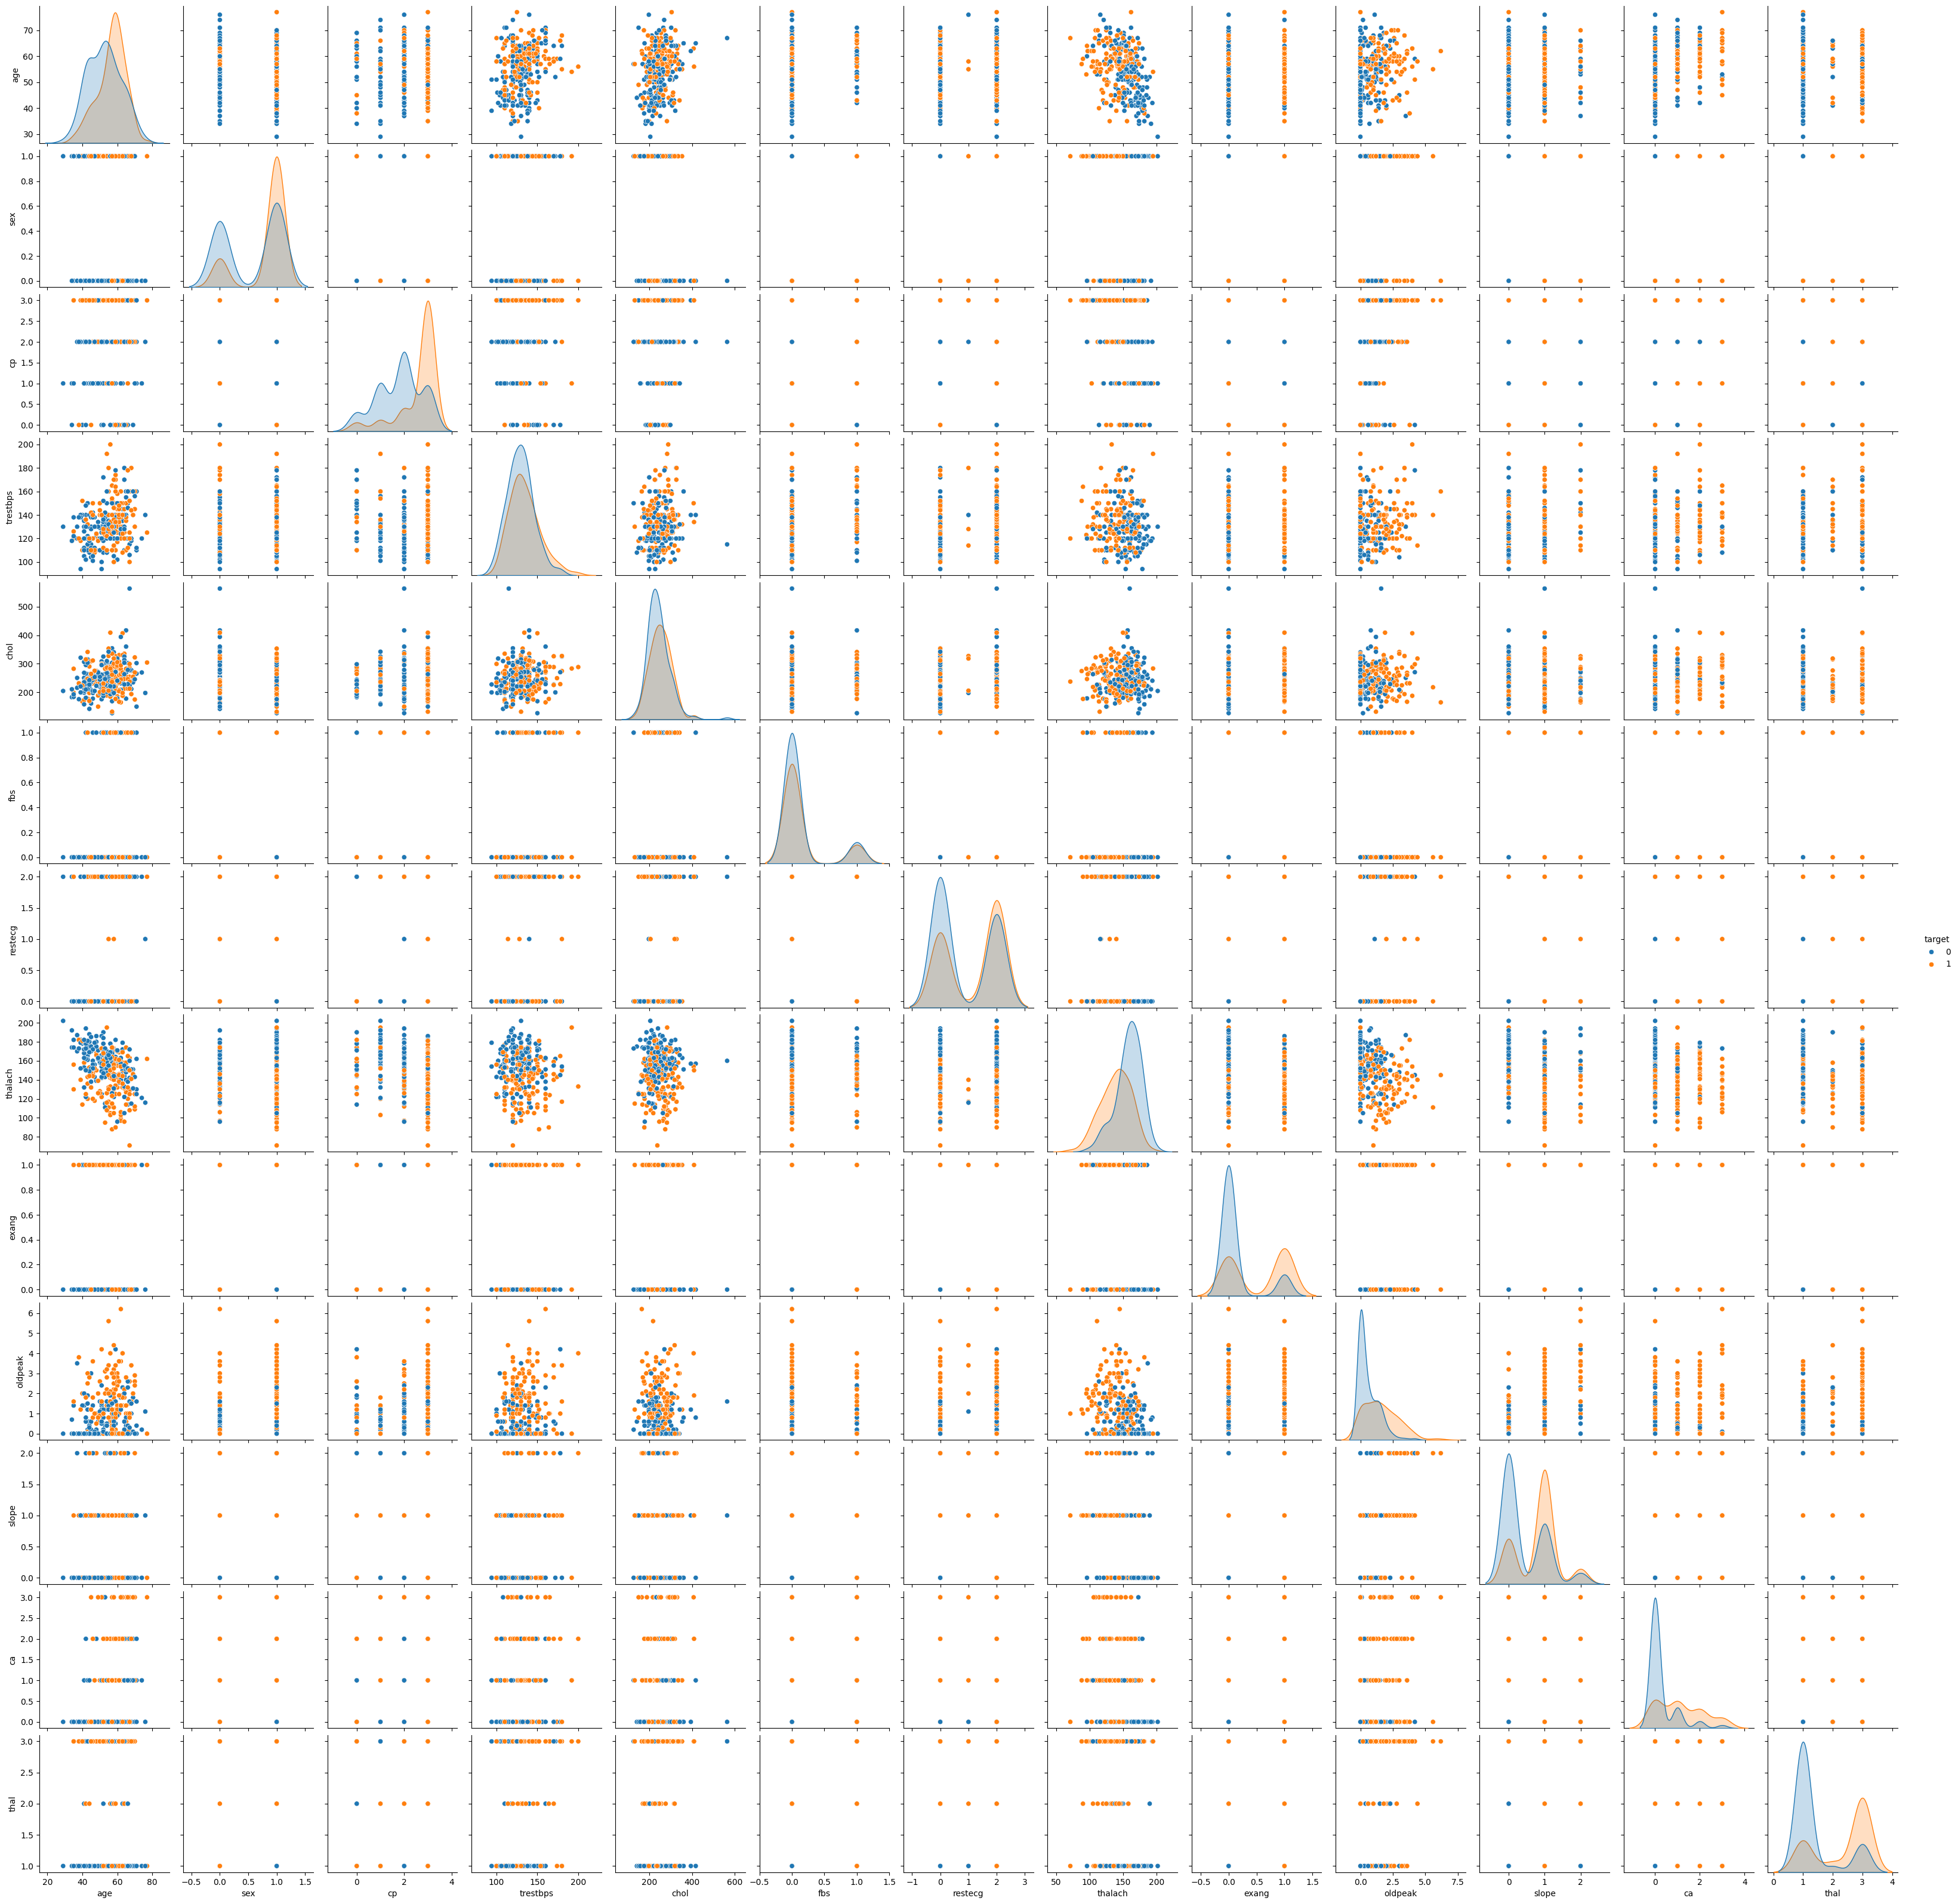

In [11]:
sns.pairplot(df, hue = 'target')

<h2>Handling and visualising the numerical features</h2>

In [12]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca'] # replacing values with categorical digits

In [13]:
for col in numerical_cols:
    print(f"\nValue counts for {col}:\n{df[col].value_counts()}")


Value counts for age:
age
58    19
57    17
54    16
59    14
52    13
60    12
51    12
56    11
62    11
44    11
41    10
64    10
63     9
67     9
53     8
43     8
42     8
55     8
61     8
65     8
45     8
48     7
50     7
66     7
46     7
49     5
47     5
39     4
68     4
35     4
70     4
40     3
69     3
71     3
37     2
34     2
38     2
29     1
77     1
74     1
76     1
Name: count, dtype: int64

Value counts for trestbps:
trestbps
120    37
130    36
140    32
110    19
150    17
128    12
138    12
160    11
125    11
112     9
132     8
118     7
135     6
124     6
108     6
145     5
134     5
152     5
170     4
122     4
100     4
105     3
142     3
180     3
115     3
126     3
136     3
94      2
102     2
148     2
178     2
144     2
146     2
172     1
117     1
155     1
104     1
200     1
165     1
101     1
174     1
158     1
192     1
129     1
123     1
106     1
156     1
154     1
114     1
164     1
Name: count, dtype: int64

Value counts f

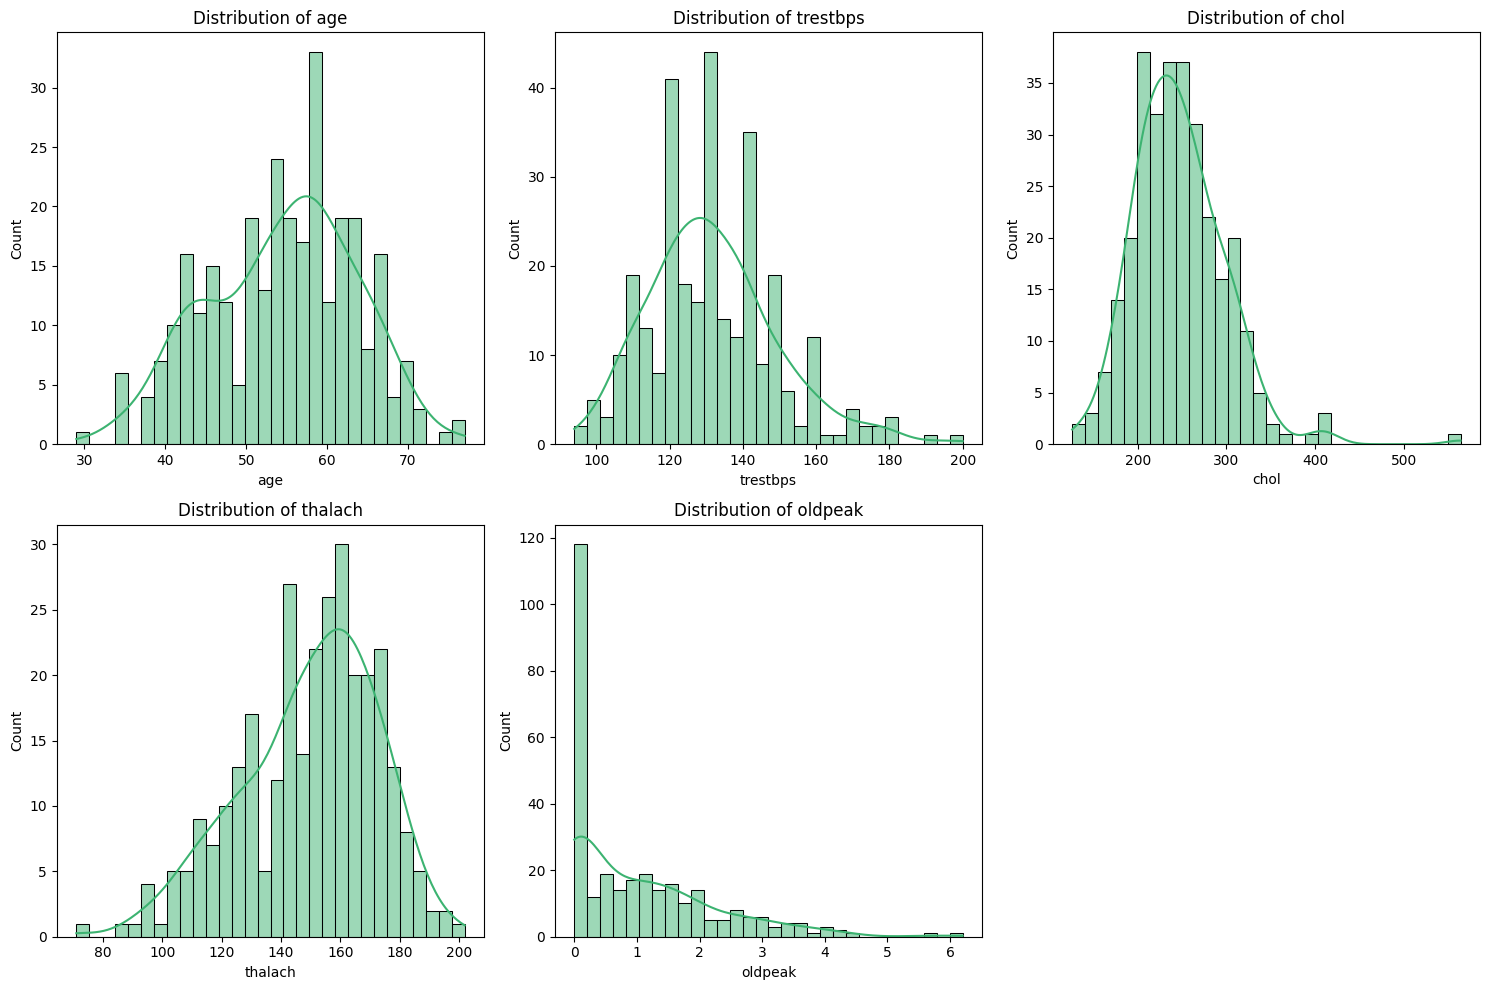

In [14]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30, color='mediumseagreen')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

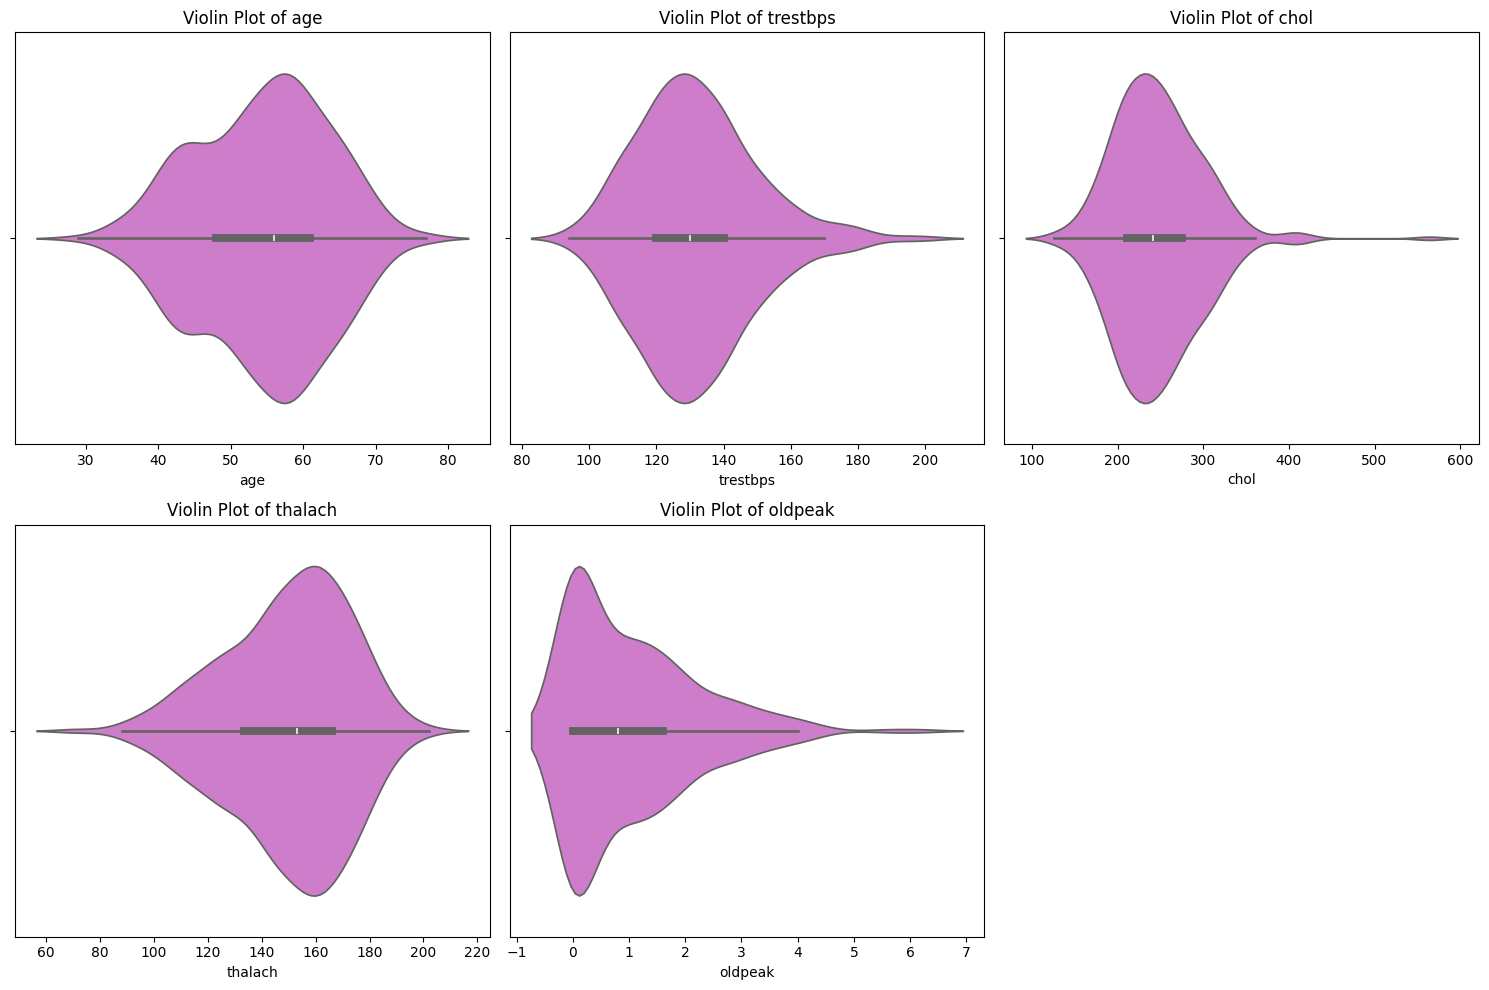

In [15]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.violinplot(x=df[col], color='orchid')
    plt.title(f'Violin Plot of {col}')
plt.tight_layout()
plt.show()

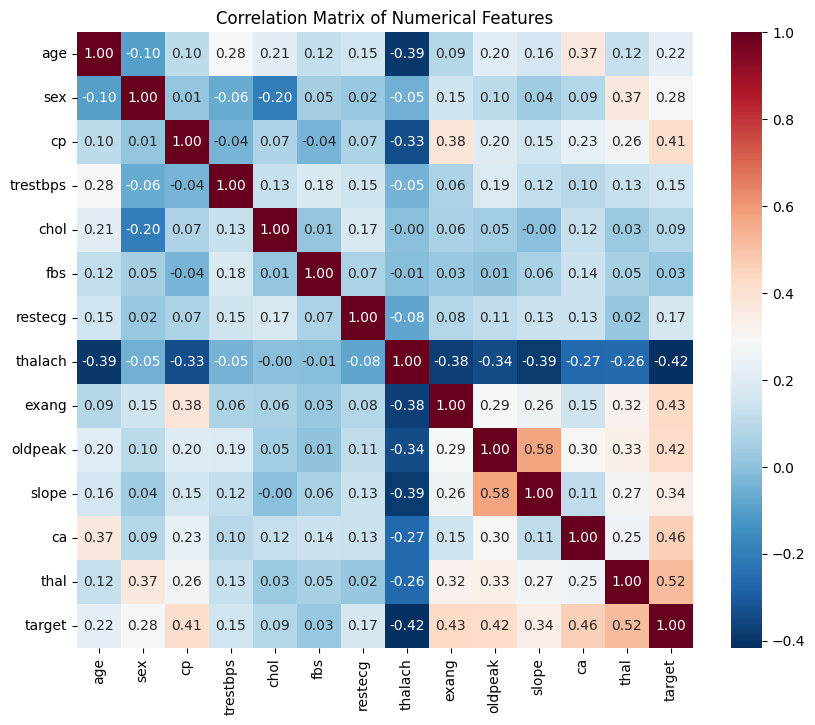

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='RdBu_r', square=True)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

<h2>Analyzing Outliers (이상치 분석)</h2> 

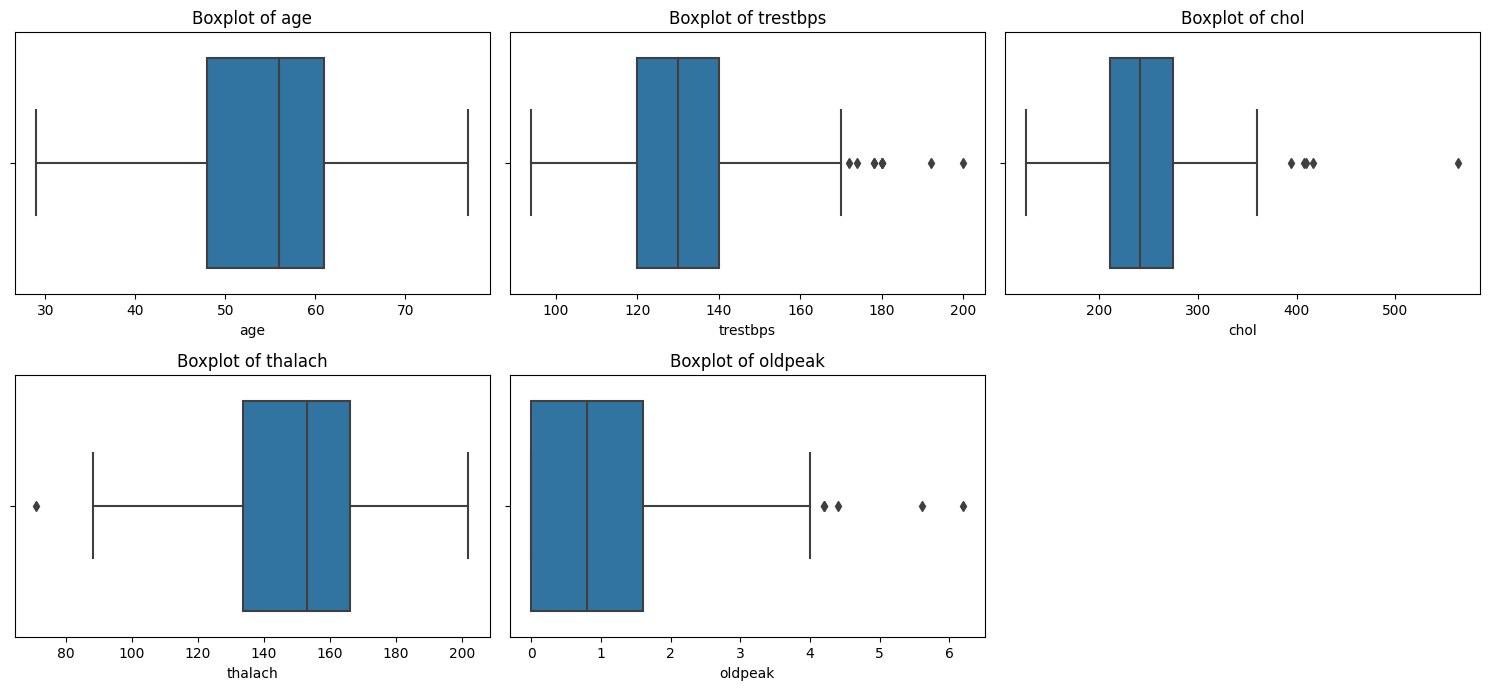

In [15]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

<h3> 이상치 분석: 박스플롯 해석 </h3>

각 박스플롯은 수치형 특성의 중심 분포와 잠재적 이상치를 보여줍니다. 다음은 세부 분석입니다:

1. 나이 (Age)
관측 결과: 유의미한 이상치가 발견되지 않음.

분포: 55-60세 중심으로 상당히 대칭적인 분포.

해석: 나이는 잘 분포되어 있으며 특별한 처리가 필요하지 않음.

2. 안정시 혈압 (trestbps)
관측 결과: 160 mmHg 이상의 몇 가지 중간 정도의 이상치.

해석:

고혈압(예: >180)이 통계적으로 이상치처럼 보일 수 있지만, 이러한 수치는 임상적으로 유효할 수 있음.

무작정 제거하지 말고 도메인 지식을 바탕으로 검토를 위해 표시해야 함.

3. 혈청 콜레스테롤 (chol)
관측 결과: 400 mg/dl 이상, 심지어 ~560까지의 여러 유의미한 이상치.

해석:

이는 고콜레스테롤혈증이나 잘못된 값을 나타낼 수 있음.

검증이 필요하며, 상황에 따라 변환(예: 로그 스케일) 또는 윈저라이징 적용.

4. 최대 심박수 (thalach)
관측 결과: 90 bpm 이하의 경미한 이상치.

해석:

이는 심장병으로 인해 운동 능력이 제한된 환자를 반영할 수 있음.

중요한 지표일 수 있으므로 보존하되, 나중에 타겟 변수와의 관계를 분석.

5. ST 하강 (oldpeak)
관측 결과: 4.0 이상의 몇 가지 높은 이상치.

해석:

이러한 높은 하강 수치는 드물지만 극심한 허혈성 사례에서 가능함.

표시하고 모델링 전에 정규화 또는 로그 변환 고려.

6. 형광투시로 착색된 주요 혈관 수 (ca)
관측 결과: 값 3에서 이상치가 보이지만 예상 범위(0-3) 내에 있음.

해석:

이는 진정한 이상치가 아님. 대부분의 환자가 더 적은 수의 혈관을 가지고 있어서 드물게 나타나는 것뿐.

교정 조치는 필요하지 않지만, 이 특성을 분석할 때 클래스 불균형을 고려해야 함.

In [17]:
df[numerical_cols].skew()

age        -0.209060
trestbps    0.706035
chol        1.135503
thalach    -0.537449
oldpeak     1.269720
dtype: float64

<h2>Handling and visualizing categorical features</h2>

In [18]:
for col in categorical_cols:
    print(f"\nValue counts for {col}:\n{df[col].value_counts()}")


Value counts for sex:
sex
1    206
0     97
Name: count, dtype: int64

Value counts for cp:
cp
3    144
2     86
1     50
0     23
Name: count, dtype: int64

Value counts for fbs:
fbs
0    258
1     45
Name: count, dtype: int64

Value counts for restecg:
restecg
0    151
2    148
1      4
Name: count, dtype: int64

Value counts for exang:
exang
0    204
1     99
Name: count, dtype: int64

Value counts for slope:
slope
0    142
1    140
2     21
Name: count, dtype: int64

Value counts for ca:
ca
0    180
1     65
2     38
3     20
Name: count, dtype: int64


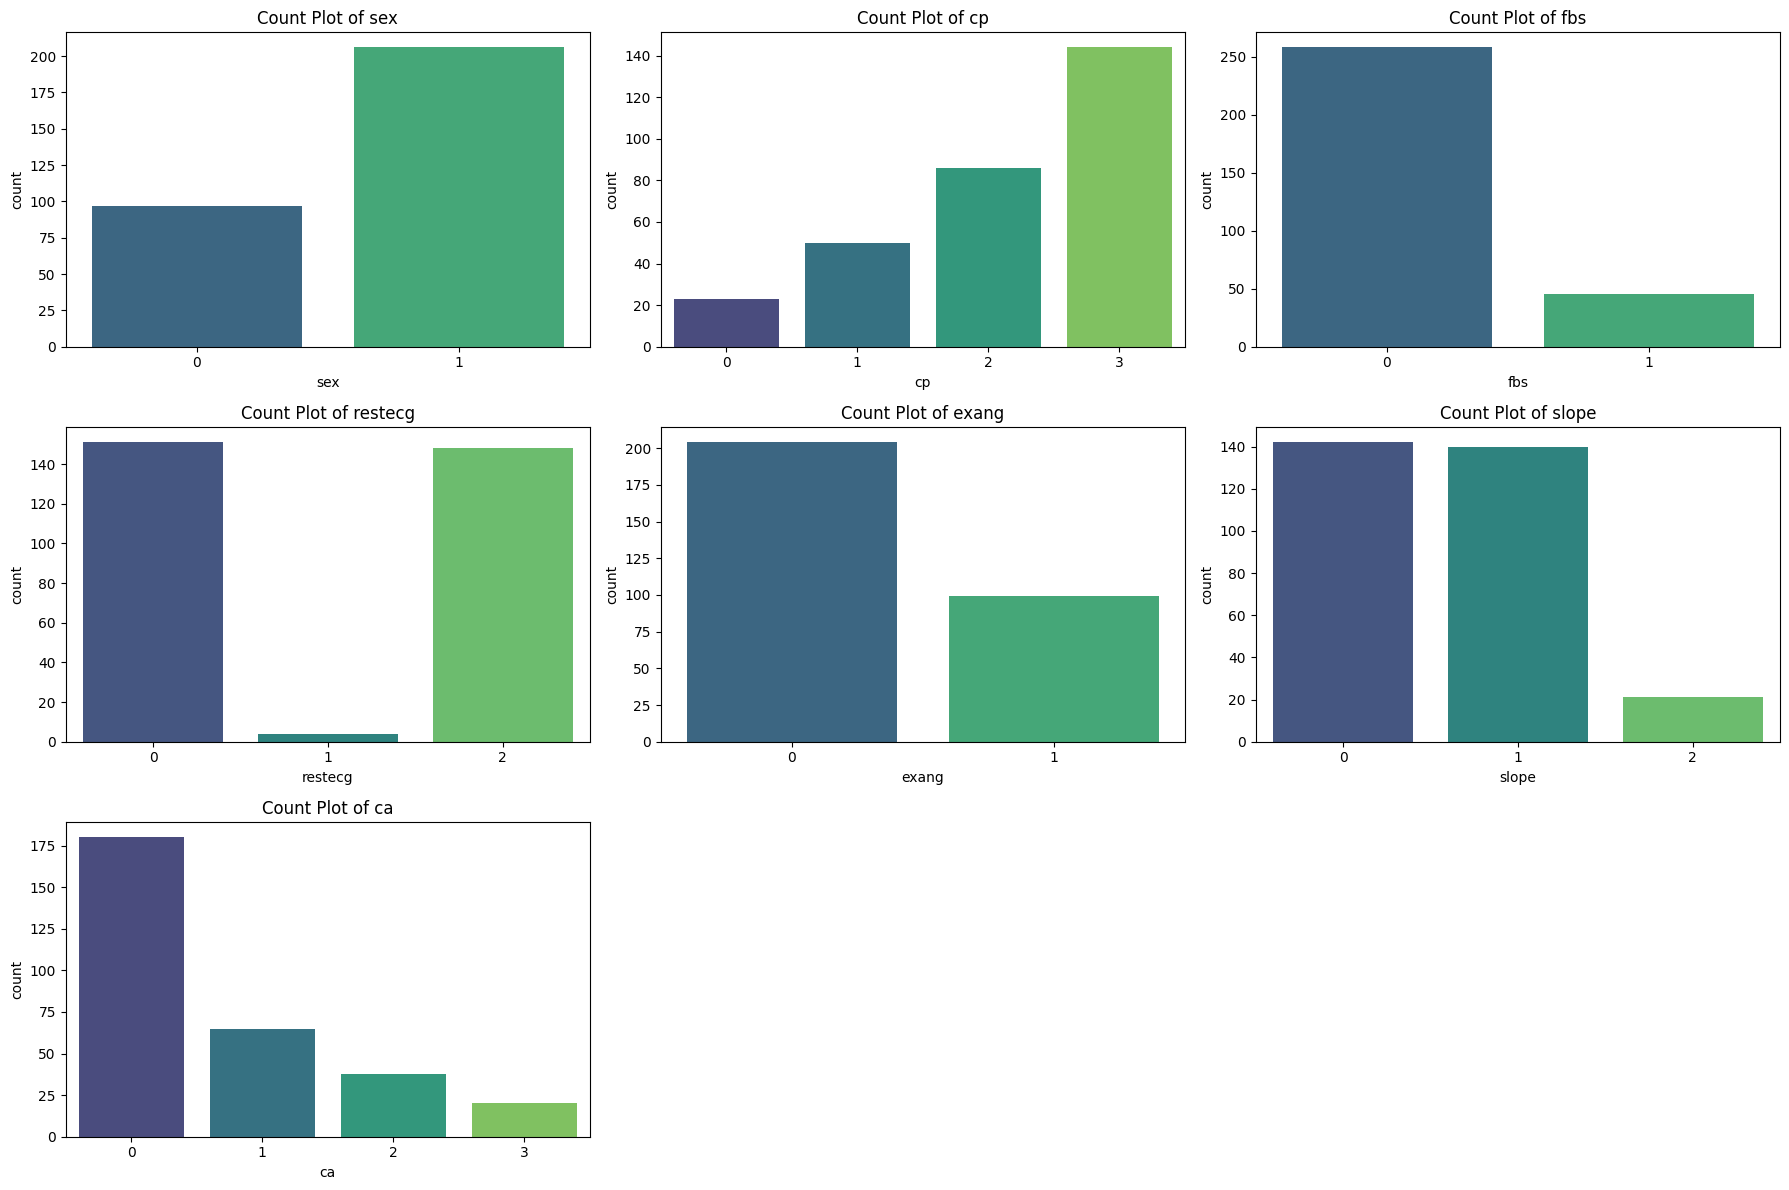

In [19]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, data=df, palette='viridis')
    plt.title(f'Count Plot of {col}')
plt.tight_layout()
plt.show()

<h2>Handling and visualizing the Target features "Num" that represents the heart disease</h2>

In [20]:
df[numerical_cols + ['target']].corr()['target'].sort_values(ascending=False)

target      1.000000
oldpeak     0.424510
age         0.223120
trestbps    0.150825
chol        0.085164
thalach    -0.417167
Name: target, dtype: float64

In [21]:
target_counts = df['target'].value_counts().sort_index()
print(target_counts)
target_percent = (target_counts / target_counts.sum()) * 100
print(target_percent)

target
0    164
1    139
Name: count, dtype: int64
target
0    54.125413
1    45.874587
Name: count, dtype: float64


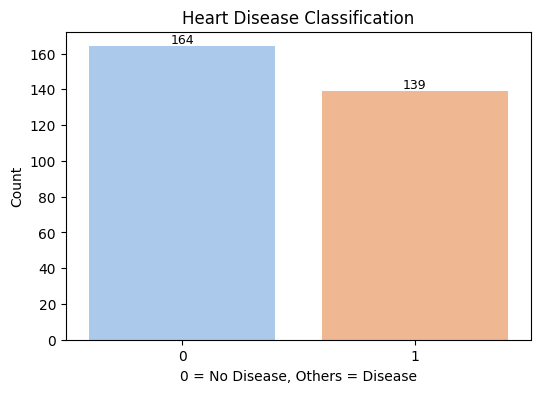

In [22]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='target', data=df, palette='pastel')

for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9)

plt.title('Heart Disease Classification')
plt.xlabel('0 = No Disease, Others = Disease')
plt.ylabel('Count')
plt.show()


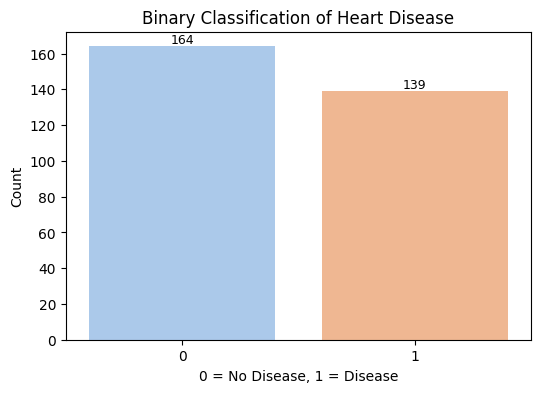

Target Class Counts:
 target
0    164
1    139
Name: count, dtype: int64

Target Class Percentages:
 target
0    54.125413
1    45.874587
Name: proportion, dtype: float64


In [23]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='target', data=df, palette='pastel')

for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9)

plt.title('Binary Classification of Heart Disease')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Count')
plt.show()

# Print counts separately
print("Target Class Counts:\n", df['target'].value_counts())
print("\nTarget Class Percentages:\n", df['target'].value_counts(normalize=True) * 100)


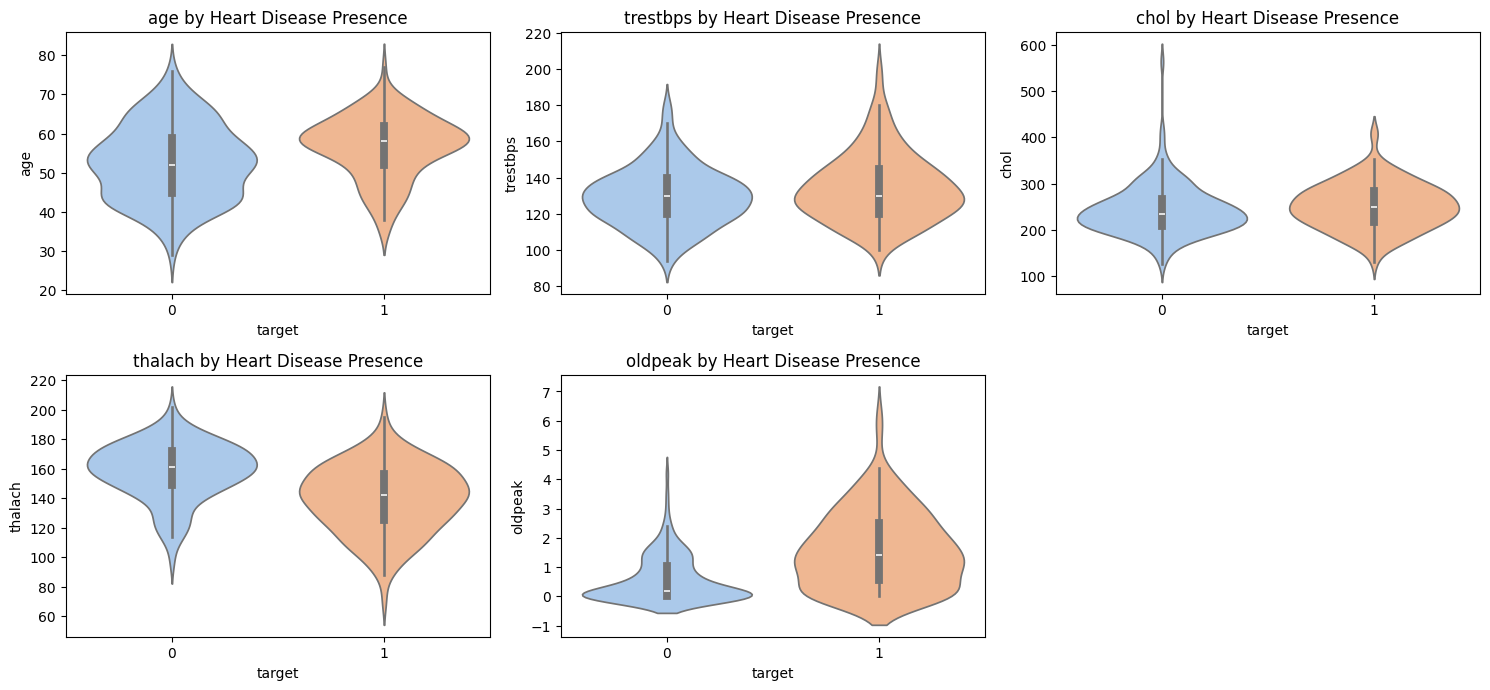

In [24]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i+1)
    sns.violinplot(data=df, x='target', y=col, palette='pastel')
    plt.title(f'{col} by Heart Disease Presence')
plt.tight_layout()
plt.show()

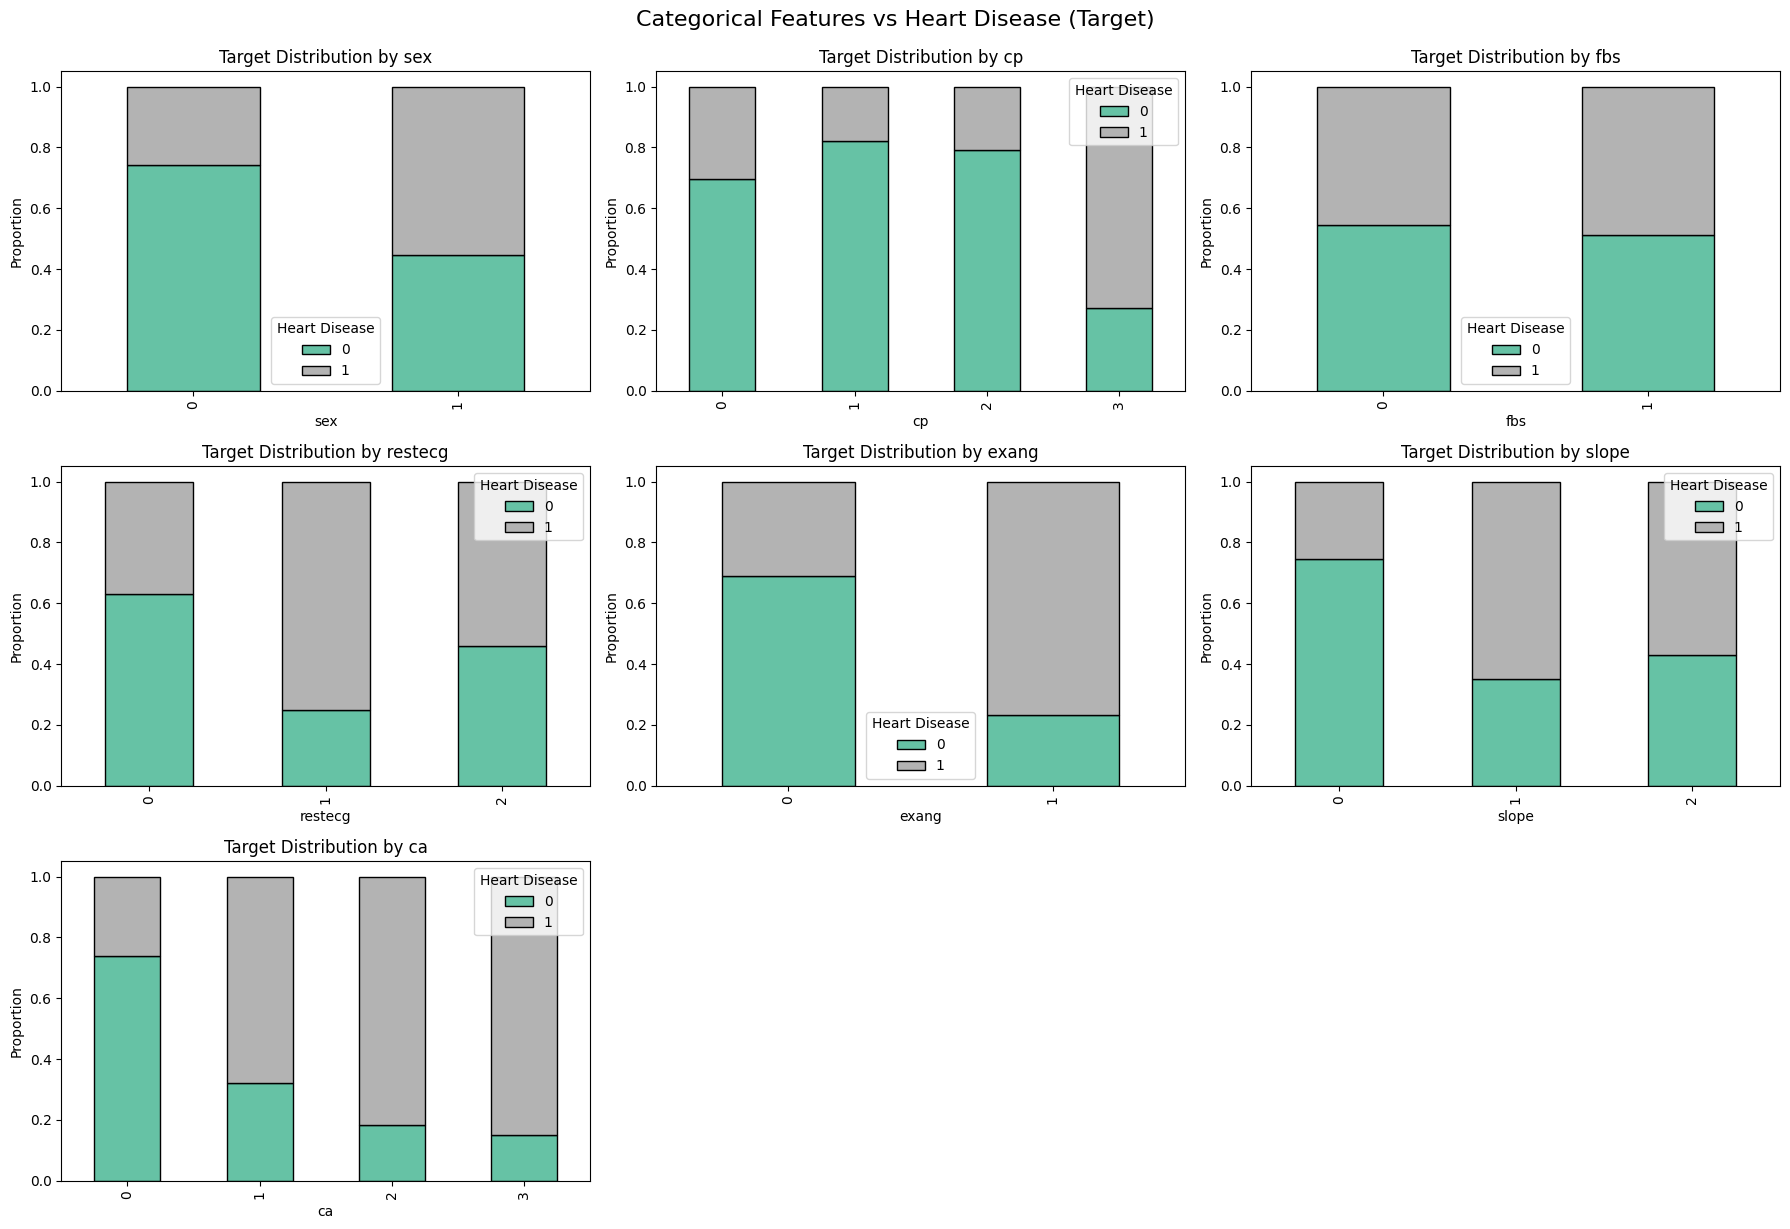

In [25]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['target'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2', edgecolor='black')
    axes[i].set_title(f'Target Distribution by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proportion')
    axes[i].legend(title='Heart Disease', loc='best')

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Categorical Features vs Heart Disease (Target)', fontsize=16, y=1.02)
plt.show()

<h3>T-Test for Numerical Columns</h3>

In [26]:
from scipy.stats import ttest_ind

print("T-tests for numerical columns:\n")
for col in numerical_cols:
    group0 = df[df['target'] == 0][col]
    group1 = df[df['target'] == 1][col]
    stat, p = ttest_ind(group0, group1, nan_policy='omit')
    print(f"{col}: p-value = {p:.4f} {'(Significant)' if p < 0.05 else '(Not significant)'}")

T-tests for numerical columns:

age: p-value = 0.0001 (Significant)
trestbps: p-value = 0.0085 (Significant)
chol: p-value = 0.1391 (Not significant)
thalach: p-value = 0.0000 (Significant)
oldpeak: p-value = 0.0000 (Significant)


<h3>Chi-sqaure Test for Catgorical Columns</h3>

In [27]:
from scipy.stats import chi2_contingency
print("Chi-square test for categorical variables:\n")
for col in categorical_cols:
    table = pd.crosstab(df[col], df['target'])
    stat, p, _, _ = chi2_contingency(table)
    print(f"{col}: p-value = {p:.4f} {'(Significant)' if p < 0.05 else '(Not significant)'}")

Chi-square test for categorical variables:

sex: p-value = 0.0000 (Significant)
cp: p-value = 0.0000 (Significant)
fbs: p-value = 0.7813 (Not significant)
restecg: p-value = 0.0066 (Significant)
exang: p-value = 0.0000 (Significant)
slope: p-value = 0.0000 (Significant)
ca: p-value = 0.0000 (Significant)


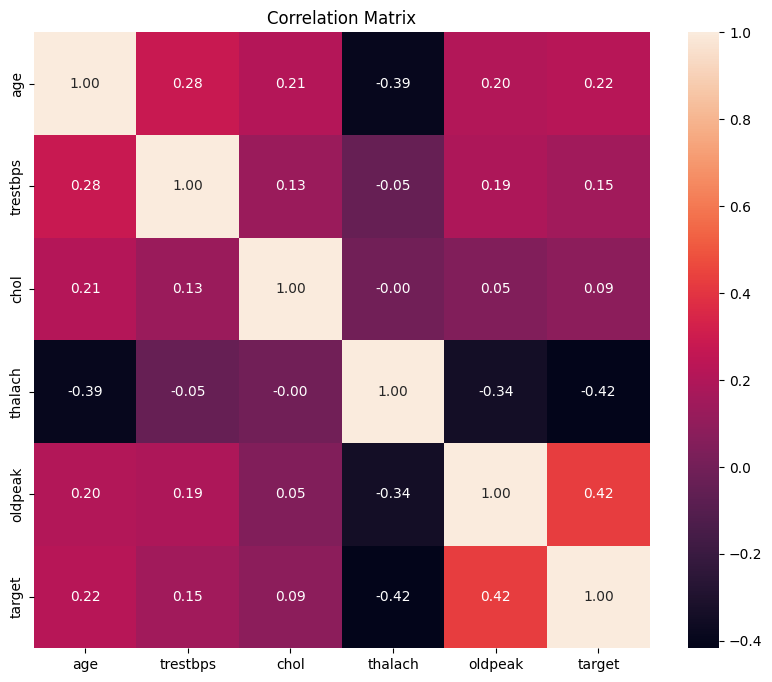

In [28]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols + ['target']].corr(), annot=True, fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()

<h2>Analyzing the age column</h2>

In [29]:
df['age'].describe()

count    303.000000
mean      54.438944
std        9.038662
min       29.000000
25%       48.000000
50%       56.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64

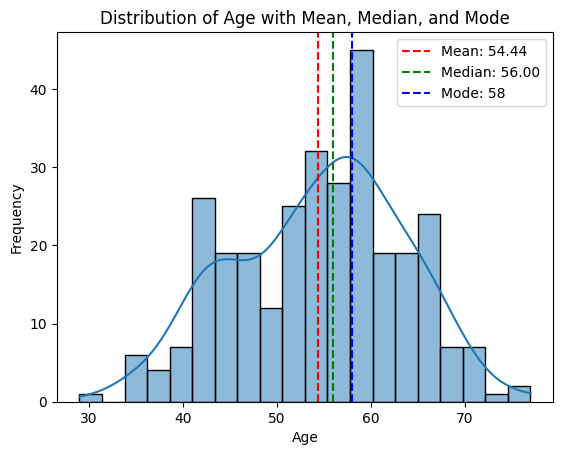

In [30]:
sns.histplot(df['age'], bins=20, kde=True)

plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.2f}")
plt.axvline(df['age'].median(), color='green', linestyle='--', label=f"Median: {df['age'].median():.2f}")
plt.axvline(df['age'].mode()[0], color='blue', linestyle='--', label=f"Mode: {df['age'].mode()[0]}")

plt.legend()
plt.title("Distribution of Age with Mean, Median, and Mode")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()


The age column distribution seems to be normaly distributed because we can clearly see the bill curve.

In [31]:
fig = px.histogram(data_frame=df, x='age')
fig.show()

print ("Mean of the dataset: ",df['age'].mean())
print ("Median of the dataset: ",df['age'].median())
print ("Mode of the dataset: ",df['age'].agg(pd.Series.mode))

Mean of the dataset:  54.43894389438944
Median of the dataset:  56.0
Mode of the dataset:  0    58
Name: age, dtype: int64


Lets explore the gender base distribution of the dataset for age column

Text(0.5, 1.0, 'Age vs Heart Disease')

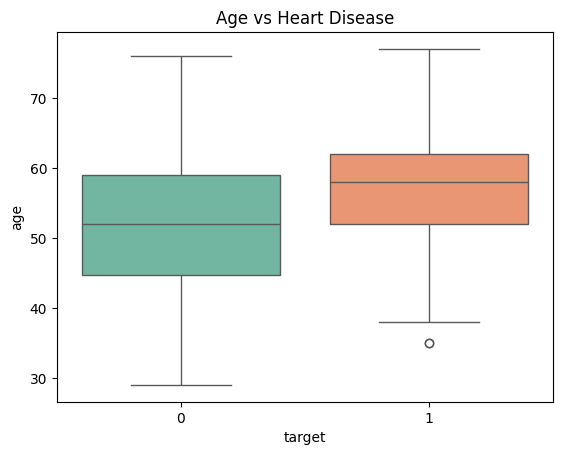

In [32]:
sns.boxplot(x='target', y='age', data=df, palette='Set2')
plt.title('Age vs Heart Disease')

In [32]:
from scipy.stats import ttest_ind
ttest_ind(df[df['target']==0]['age'], df[df['target']==1]['age'], nan_policy='omit')


TtestResult(statistic=-3.9711002262936557, pvalue=8.955636917529656e-05, df=301.0)

Text(0.5, 1.0, 'Age vs Max Heart Rate by Target')

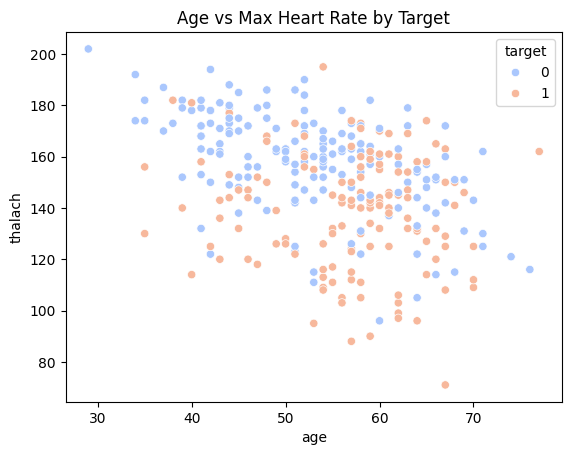

In [33]:
sns.scatterplot(x='age', y='thalach', hue='target', data=df, palette='coolwarm')
plt.title("Age vs Max Heart Rate by Target")


In [34]:
fig = px.histogram(data_frame=df, x='age', color= 'sex')
fig.show()

In [35]:
df['sex'].value_counts()

sex
1    206
0     97
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='count'>

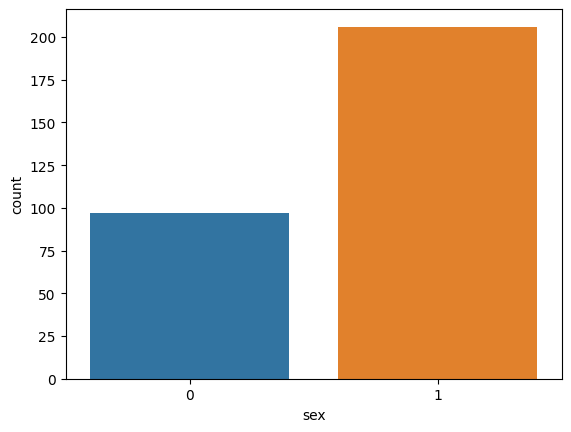

In [36]:
sns.countplot(df,x='sex')

In [36]:
male_count = 206
female_count = 97

total_count = male_count + female_count

# calculate percentages
male_percentage = (male_count/total_count)*100
female_percentages = (female_count/total_count)*100

# display the results
print(f'Male percentage in the data: {male_percentage:.2f}%')
print(f'Female percentage in the data : {female_percentages:.2f}%')

# Difference
difference_percentage = ((male_count - female_count)/female_count) * 100
print(f'Males are {difference_percentage:.2f}% more than female in the data.')


Male percentage in the data: 67.99%
Female percentage in the data : 32.01%
Males are 112.37% more than female in the data.


In [37]:
df.groupby('sex')['age'].value_counts()

sex  age
0    62     7
     58     6
     54     5
     60     5
     63     5
           ..
1    38     2
     37     1
     77     1
     34     1
     29     1
Name: count, Length: 73, dtype: int64

## Exploring CP (Chest Pain) column

In [38]:
df['cp'].value_counts()

cp
3    144
2     86
1     50
0     23
Name: count, dtype: int64

<Axes: xlabel='cp', ylabel='count'>

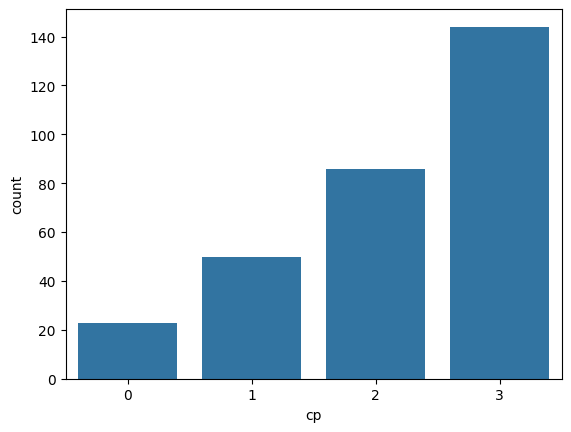

In [39]:
sns.countplot(df,x='cp')

<Axes: xlabel='cp', ylabel='count'>

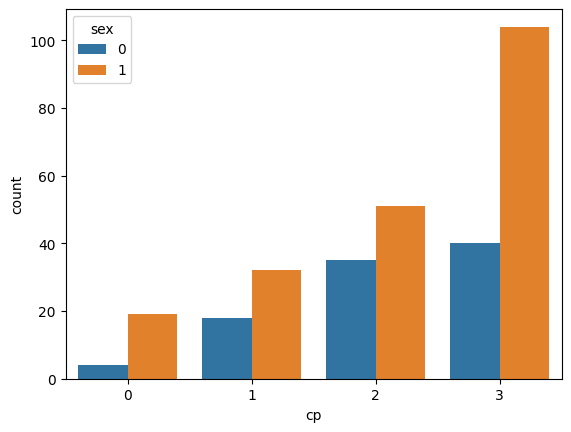

In [40]:
sns.countplot(df, x='cp', hue= 'sex')

In [41]:

fig = px.histogram(data_frame=df, x='age', color='cp')
fig.show()

### Let's explore the trestbps (resting blood pressure) column:

In [42]:

df['trestbps'].describe()

count    303.000000
mean     131.689769
std       17.599748
min       94.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

Text(0, 0.5, 'Count')

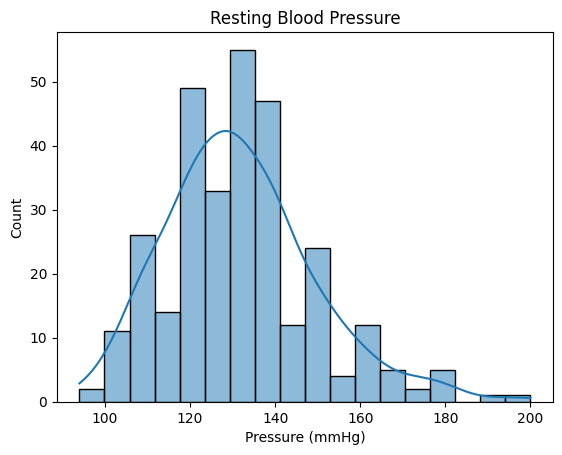

In [43]:
sns.histplot(data=df, x='trestbps', kde=True,)

plt.title('Resting Blood Pressure')
plt.xlabel('Pressure (mmHg)')
plt.ylabel('Count')

<Axes: xlabel='trestbps', ylabel='Count'>

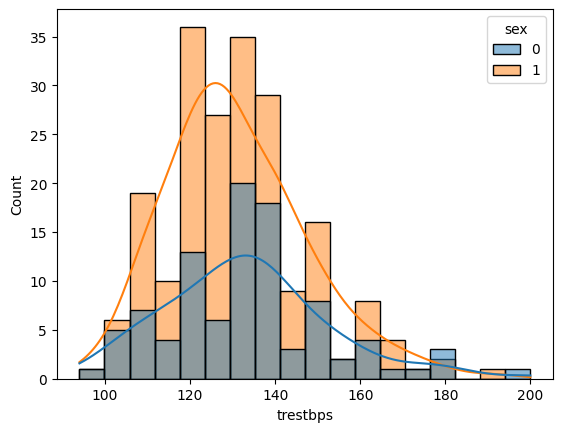

In [44]:
sns.histplot(df, x='trestbps', kde=True, hue ='sex') 

<h2>Impute missing values using iterative imputer for selected columns.</h2>

columns are selected based on data types (floating data type)
because imputer only works with the floating data types.

selected columns are:
1. thal
2. ca

In [45]:
imputer = SimpleImputer(strategy='most_frequent')
df['ca'] = imputer.fit_transform(df[['ca']]).ravel()
df['thal'] = imputer.fit_transform(df[['thal']]).ravel()

In [47]:
# let's check again for missing values
(df.isnull().sum()).sort_values(ascending=False)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Now Missing values are imputed and there is no missing values in the columns....

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [46]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [49]:
X = df.drop(['target'], axis=1)
y = df['target']

<h3>Splitting the dataset into training and testing sets</h3>

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [51]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [52]:
scaler = StandardScaler() 

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])


<h2>MODEL DEVELOPMENT</h2>

<h3>1. Logistic Regression</h3>

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, classification_report
import numpy as np

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression with different penalties
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': np.logspace(-3, 3, 7),
    'solver': ['saga'],
    'l1_ratio': [0, 0.25, 0.5, 0.75, 1] 
}

logreg = LogisticRegression(max_iter=1000)

grid = GridSearchCV(logreg, param_grid, cv=cv, scoring='f1', n_jobs=-1, error_score='raise')
grid.fit(X_train_scaled, y_train)

cal_lgr = CalibratedClassifierCV(grid.best_estimator_, cv=cv)
cal_lgr.fit(X_train_scaled, y_train)

y_pred = cal_lgr.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



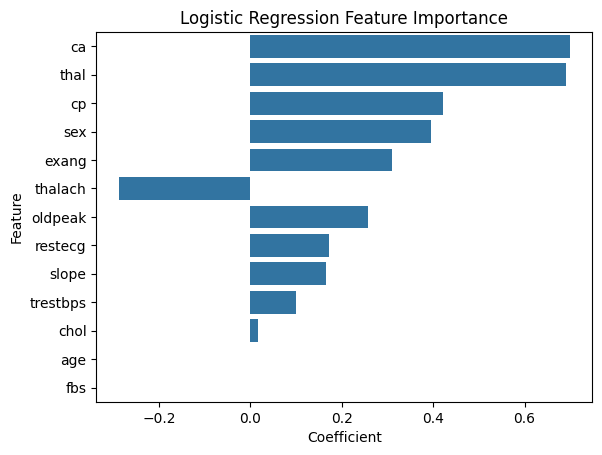

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

coef = grid.best_estimator_.coef_[0]
features = X_train_scaled.columns
importance_df = pd.DataFrame({'Feature': features, 'Coefficient': coef})
importance_df = importance_df.sort_values(by='Coefficient', key=abs, ascending=False)

sns.barplot(data=importance_df, x='Coefficient', y='Feature')
plt.title("Logistic Regression Feature Importance")
plt.show()


<h3>2. K-Nearest Neighbors (KNN)</h3>

**KNN(K-최근접 이웃)**은 가장 직관적이고 이해하기 쉬운 머신러닝 알고리즘 중 하나입니다.

**핵심 개념:**
- **K값**: 고려할 이웃의 개수 (예: K=5이면 가장 가까운 5개 데이터 포인트 참조)
- **거리 측정**: 유클리디안 거리, 맨하탄 거리 등을 사용해 데이터 간 거리 계산
- **다수결 투표**: K개의 가장 가까운 이웃들의 클래스 중 가장 많은 클래스로 예측

**장점:**
- 구현이 간단하고 이해하기 쉬움
- 비선형 패턴을 자연스럽게 학습 가능
- 새로운 데이터에 대해 즉시 예측 가능 (lazy learning)

**단점:**
- 큰 데이터셋에서 예측 시간이 오래 걸림
- 차원의 저주(curse of dimensionality)에 민감
- 모든 특성을 동일하게 취급하므로 특성 스케일링 필요

**K값 선택의 중요성:**
- K가 너무 작으면: 노이즈에 민감 (과적합)
- K가 너무 크면: 경계가 너무 부드러워짐 (과소적합)

In [55]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': list(range(3, 22, 2)), 
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

cal_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=cv, scoring='f1', n_jobs=-1)
cal_knn.fit(X_train, y_train)

y_pred_knn = cal_knn.predict(X_test)
print("Best KNN params:", cal_knn.best_params_)
print(classification_report(y_test, y_pred_knn))

Best KNN params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



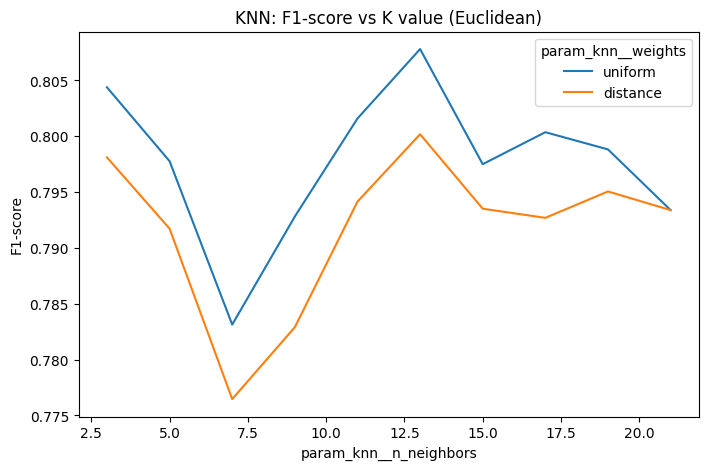

In [56]:
results = pd.DataFrame(cal_knn.cv_results_)
scores_k = results[results['param_knn__metric'] == 'euclidean']

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.lineplot(data=scores_k, x='param_knn__n_neighbors', y='mean_test_score', hue='param_knn__weights')
plt.title("KNN: F1-score vs K value (Euclidean)")
plt.ylabel("F1-score")
plt.show()


이 그래프는 흉통(Chest Pain) 유형의 분포를 보여주는 카운트 플롯입니다.

그래프 설명:

X축: 흉통 유형 (cp 변수)

0: 무증상 (Asymptomatic)
1: 비전형적 협심증 (Atypical angina)
2: 비협심증성 흉통 (Non-anginal pain)
3: 전형적 협심증 (Typical angina)
Y축: 각 흉통 유형의 환자 수 (빈도)

임상적 의미:

흉통 유형은 심장병 진단에서 매우 중요한 증상 중 하나입니다
각 유형은 심장병 위험도와 다른 연관성을 가집니다:
전형적 협심증: 심장병 위험이 높음
비전형적 협심증: 중간 위험도
비협심증성 흉통: 낮은 위험도
무증상: 증상이 없지만 심장병이 있을 수 있음
분석 목적:

데이터 불균형 확인: 어떤 흉통 유형이 데이터에 많이/적게 포함되어 있는지 확인
특성 이해: 환자들의 흉통 증상 패턴 파악
모델링 준비: 클래스 불균형이 있다면 모델링 시 가중치 조정 고려
이 그래프는 심장병 예측 모델에서 흉통 유형이 얼마나 중요한 예측 변수인지를 이해하는 첫 단계입니다.

<h3>3. Support Vector Machine (SVM)</h3>

**SVM(서포트 벡터 머신)**은 분류와 회귀 문제에 사용되는 강력한 머신러닝 알고리즘입니다.

**핵심 개념:**
- **서포트 벡터**: 결정 경계에 가장 가까이 있는 데이터 포인트들
- **결정 경계(Decision Boundary)**: 클래스를 구분하는 최적의 경계선
- **마진**: 결정 경계와 서포트 벡터 사이의 거리 (마진을 최대화하는 것이 목표)

**장점:**
- 고차원 데이터에서도 효과적
- 커널 트릭을 사용해 비선형 문제도 해결 가능
- 과적합에 상대적으로 강함

**단점:**
- 큰 데이터셋에서는 학습 시간이 오래 걸림
- 확률값 제공이 기본적으로 안 됨 (probability=True 옵션 필요)

심장병 예측에서 SVM은 복잡한 패턴을 잘 찾아내어 높은 정확도를 보일 것으로 예상됩니다.

In [57]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, class_weight='balanced'))
])

param_grid_svm = {
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto'],     # For RBF/poly
    'svm__degree': [2, 3]                # Only relevant for 'poly'
}

grid_svm = GridSearchCV(
    svm_pipeline, param_grid=param_grid_svm,
    cv=cv, scoring='f1', n_jobs=-1
)
grid_svm.fit(X_train, y_train)

cal_svm = CalibratedClassifierCV(estimator=grid_svm.best_estimator_, cv=cv)
cal_svm.fit(X_train, y_train)

y_pred_svm = cal_svm.predict(X_test)
print("Best SVM Params:", grid_svm.best_params_)
print(classification_report(y_test, y_pred_svm))


Best SVM Params: {'svm__C': 0.1, 'svm__degree': 2, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.90      0.79      0.84        33
           1       0.78      0.89      0.83        28

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



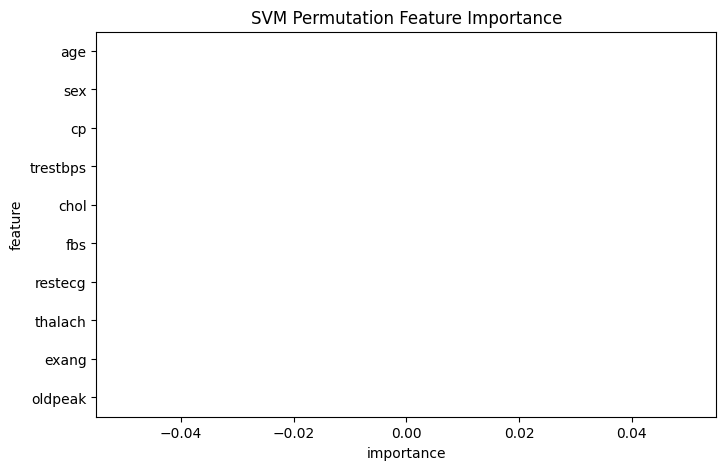

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

X_test_scaled = grid_svm.best_estimator_.named_steps['scaler'].transform(X_test)

perm_importance = permutation_importance(cal_svm, X_test_scaled, y_test, n_repeats=20, random_state=42)

importances = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm_importance.importances_mean
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importances.head(10), y='feature', x='importance')
plt.title("SVM Permutation Feature Importance")
plt.show()


<h3>4. Random Forest Classifier (RF) </h3>

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_rf = GridSearchCV(
    rf_model, param_grid_rf, cv=cv,
    scoring='f1', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

cal_rf = CalibratedClassifierCV(grid_rf.best_estimator_, cv=cv)
cal_rf.fit(X_train, y_train)

y_pred_rf = cal_rf.predict(X_test)
print("Best RF Params:", grid_rf.best_params_)
print(classification_report(y_test, y_pred_rf))


Best RF Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        33
           1       0.90      0.93      0.91        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



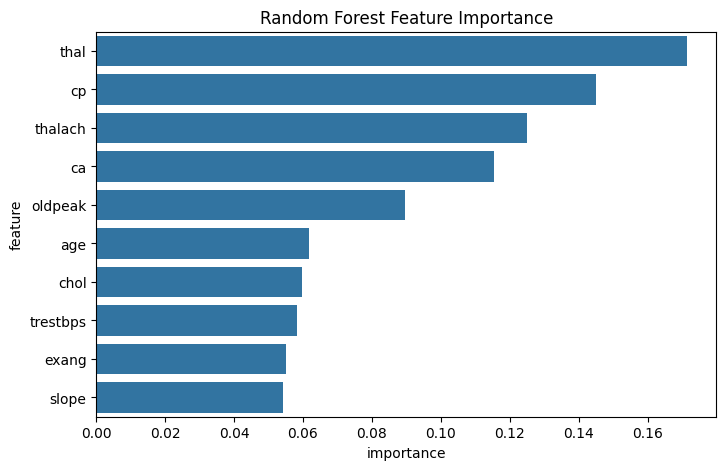

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cal_rf.estimator.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp.head(10), y='feature', x='importance')
plt.title("Random Forest Feature Importance")
plt.show()


<h3>5. XGBoost Classifier</h3>

In [61]:
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report

param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=cv, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

cal_xgb = CalibratedClassifierCV(grid_xgb.best_estimator_, cv=cv)
cal_xgb.fit(X_train, y_train)

y_pred_xgb = cal_xgb.predict(X_test)
print("Best XGBoost Params:", grid_xgb.best_params_)
print(classification_report(y_test, y_pred_xgb))


Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



<Figure size 1000x500 with 0 Axes>

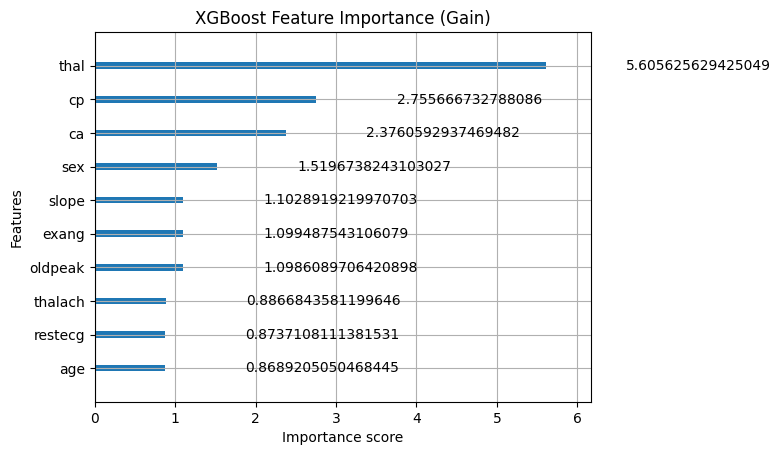

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plot_importance(grid_xgb.best_estimator_, importance_type='gain', max_num_features=10)
plt.title("XGBoost Feature Importance (Gain)")
plt.show()


<h3>6. Light GBM</h3>

**LightGBM(Light Gradient Boosting Machine)**은 Microsoft에서 개발한 고성능 그래디언트 부스팅 프레임워크입니다.

**핵심 개념:**
- **그래디언트 부스팅**: 약한 학습기들을 순차적으로 결합하여 강한 모델 생성
- **리프 중심 트리 성장**: 다른 알고리즘과 달리 리프 단위로 트리를 확장 (메모리 효율적)
- **히스토그램 기반 알고리즘**: 연속형 특성을 히스토그램으로 변환하여 속도 향상

**장점:**
- **빠른 훈련 속도**: XGBoost보다 훨씬 빠름
- **낮은 메모리 사용량**: 메모리 효율적인 구조
- **높은 정확도**: 대부분의 데이터셋에서 우수한 성능
- **범주형 특성 자동 처리**: 별도 인코딩 없이 처리 가능

**단점:**
- **작은 데이터셋에서 과적합**: 데이터가 적을 때 과적합 경향
- **하이퍼파라미터 민감성**: 파라미터 튜닝이 중요

**주요 파라미터:**
- `num_leaves`: 리프 노드 수 (트리 복잡도 조절)
- `learning_rate`: 학습률 (0.05-0.1 권장)
- `max_depth`: 트리 최대 깊이

심장병 예측에서 LightGBM은 빠른 속도와 높은 정확도를 동시에 제공할 것으로 기대됩니다.

In [63]:
from lightgbm import LGBMClassifier, plot_importance
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report

param_grid_lgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [15, 31, 63]
}

lgb = LGBMClassifier(class_weight='balanced', random_state=42)

grid_lgb = GridSearchCV(lgb, param_grid_lgb, cv=cv, scoring='f1', n_jobs=-1)
grid_lgb.fit(X_train, y_train)

cal_lgb = CalibratedClassifierCV(grid_lgb.best_estimator_, cv=cv)
cal_lgb.fit(X_train, y_train)

y_pred_lgb = cal_lgb.predict(X_test)
print("Best LightGBM Params:", grid_lgb.best_params_)
print(classification_report(y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 111, number of negative: 131
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000195 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 237
[LightGBM] [Info] Number of data points in the train set: 242, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

<Figure size 1000x500 with 0 Axes>

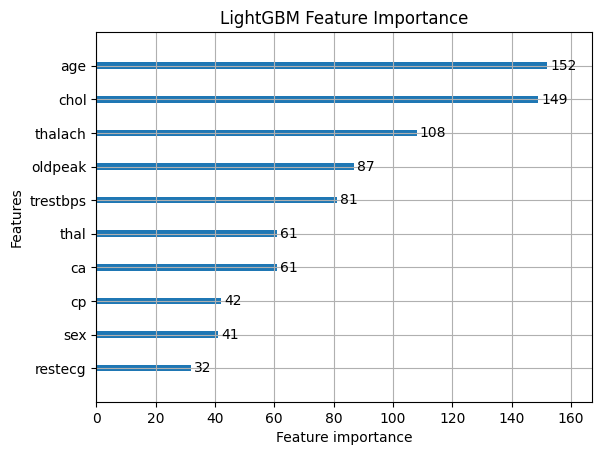

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plot_importance(grid_lgb.best_estimator_, max_num_features=10)
plt.title("LightGBM Feature Importance")
plt.show()

<h2>Evaluation of Traditional Machine learning models </h2>

In [65]:
models = {
    'Logistic Regression': cal_lgr,  
    'KNN': cal_knn,            
    'SVM': cal_svm,
    'Random Forest': cal_rf,
    'XGBoost': cal_xgb,
    'LightGBM': cal_lgb
}

In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'Best Params': getattr(model, 'best_params_', 'N/A') 
    }

def evaluate_all_models(models: dict, X_test, y_test):
    results = [evaluate_model(name, model, X_test, y_test) for name, model in models.items()]
    df_results = pd.DataFrame(results).sort_values(by='F1-score', ascending=False)
    
    print("Model Comparison:\n")
    print(df_results[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']])
    
    best_model_row = df_results.iloc[0]
    print(f"\nBest Model: {best_model_row['Model']}")
    
    return df_results


In [68]:
df_results = evaluate_all_models(models, X_test, y_test)

Model Comparison:

                 Model  Accuracy  Precision    Recall  F1-score
3        Random Forest  0.918033   0.896552  0.928571  0.912281
1                  KNN  0.885246   0.838710  0.928571  0.881356
5             LightGBM  0.885246   0.838710  0.928571  0.881356
4              XGBoost  0.885246   0.838710  0.928571  0.881356
2                  SVM  0.836066   0.781250  0.892857  0.833333
0  Logistic Regression  0.540984   0.000000  0.000000  0.000000

Best Model: Random Forest


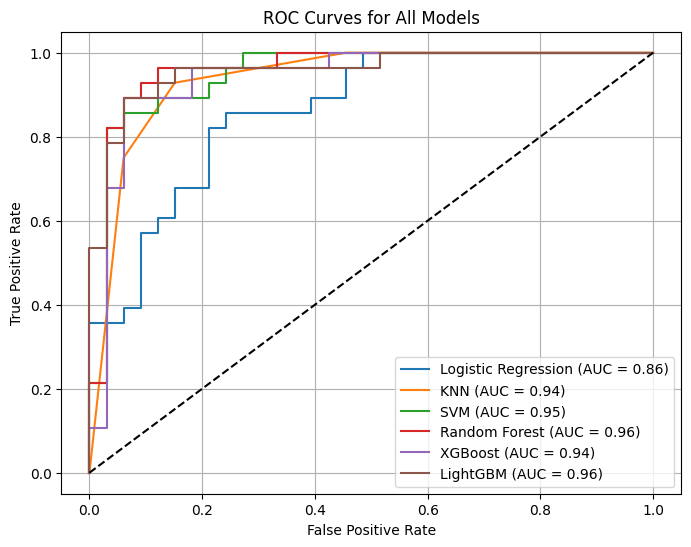

In [66]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()


<Figure size 640x480 with 0 Axes>

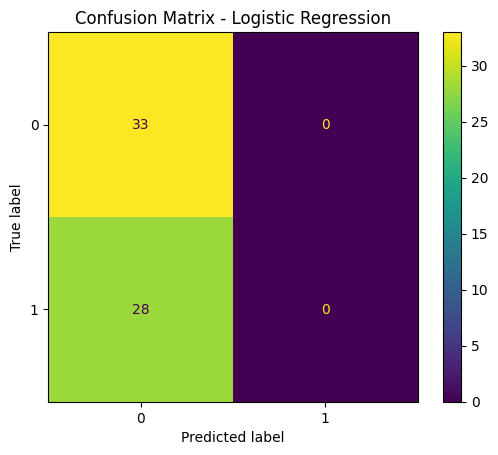

<Figure size 640x480 with 0 Axes>

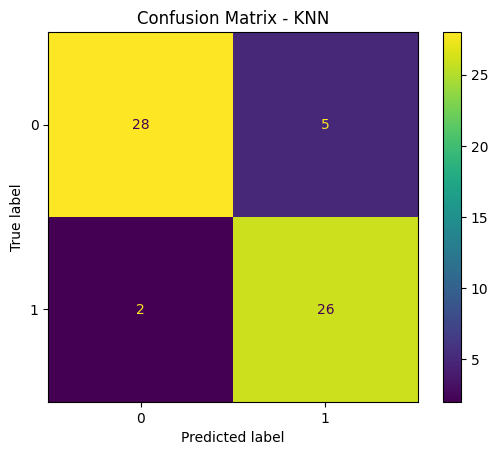

<Figure size 640x480 with 0 Axes>

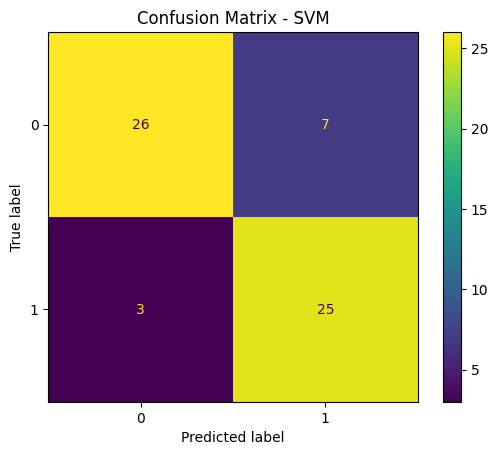

<Figure size 640x480 with 0 Axes>

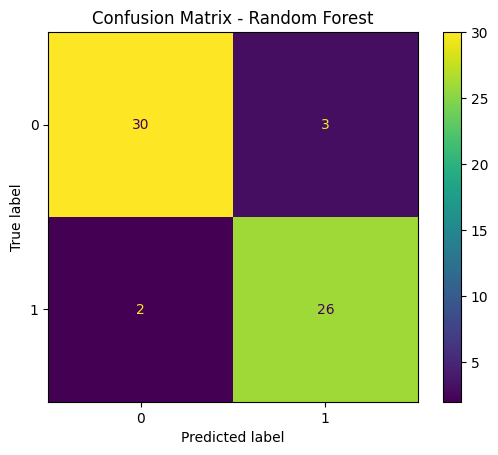

<Figure size 640x480 with 0 Axes>

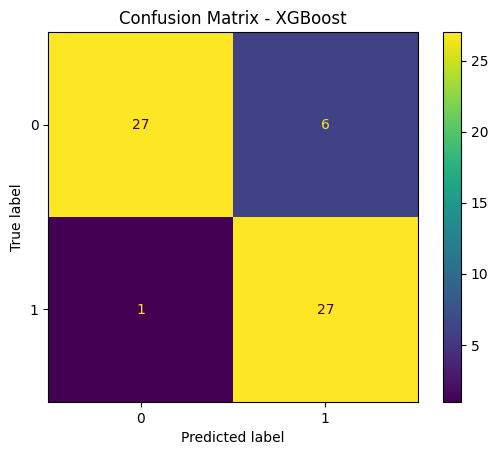

<Figure size 640x480 with 0 Axes>

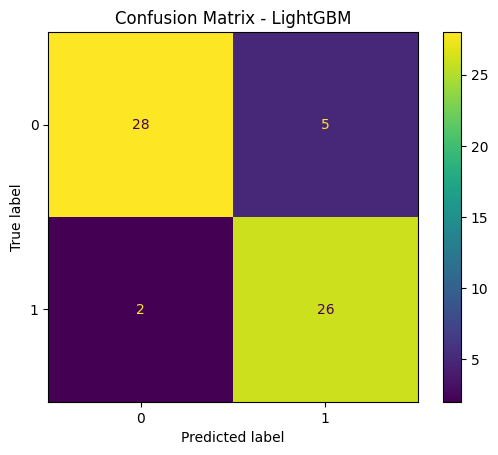

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in models.items():
    plt.figure()
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()


<h2>MLP model (Deep Learning)</h2>

In [79]:
import torch 
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


In [80]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class HeartDiseasePredictor(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.3):
        super(HeartDiseasePredictor, self).__init__()

        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)

        self.fc4 = nn.Linear(64, 32)
        self.bn4 = nn.BatchNorm1d(32)

        self.out = nn.Linear(32, 1)

        self.dropout = nn.Dropout(dropout_rate)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        x = self.dropout(self.activation(self.bn1(self.fc1(x))))
        x = self.dropout(self.activation(self.bn2(self.fc2(x))))
        x = self.dropout(self.activation(self.bn3(self.fc3(x))))
        x = self.dropout(self.activation(self.bn4(self.fc4(x))))
        return self.out(x)


In [81]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
from sklearn.metrics import f1_score, classification_report
from torch.utils.data import TensorDataset, DataLoader

model = HeartDiseasePredictor(input_dim=X_train.shape[1])
optimizer = optim.AdamW(model.parameters(), lr=0.001)

# Class imbalance handling
pos_weight = torch.tensor([len(y_train) / sum(y_train) - 1])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Training loop
n_epochs = 50
best_val_loss = float('inf')
patience = 5
early_stop_counter = 0

train_losses, val_losses = [], []

for epoch in range(n_epochs):
    model.train()
    train_loss = 0.0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = model(X_test_tensor)
        val_loss = criterion(val_logits, y_test_tensor).item()
        scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1: Train Loss = 0.7625, Val Loss = 0.7250
Epoch 2: Train Loss = 0.6775, Val Loss = 0.6958
Epoch 3: Train Loss = 0.7155, Val Loss = 0.6534
Epoch 4: Train Loss = 0.6644, Val Loss = 0.6488
Epoch 5: Train Loss = 0.6604, Val Loss = 0.6289
Epoch 6: Train Loss = 0.6536, Val Loss = 0.6118
Epoch 7: Train Loss = 0.6749, Val Loss = 0.6065
Epoch 8: Train Loss = 0.6280, Val Loss = 0.5992
Epoch 9: Train Loss = 0.6250, Val Loss = 0.5974
Epoch 10: Train Loss = 0.6154, Val Loss = 0.5830
Epoch 11: Train Loss = 0.6229, Val Loss = 0.5761
Epoch 12: Train Loss = 0.6397, Val Loss = 0.5710
Epoch 13: Train Loss = 0.6318, Val Loss = 0.5749
Epoch 14: Train Loss = 0.6195, Val Loss = 0.5850
Epoch 15: Train Loss = 0.6450, Val Loss = 0.5774
Epoch 16: Train Loss = 0.6071, Val Loss = 0.5798
Epoch 17: Train Loss = 0.5979, Val Loss = 0.5777
Early stopping triggered.


<h3>Evaluation Metrics</h3>

In [82]:
model.load_state_dict(best_model_state)
model.eval()

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_tensor)).numpy()

best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.3, 0.7, 0.01):
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t
\
final_preds = (probs >= best_thresh).astype(int)
print(f"\nBest threshold: {best_thresh:.2f}, F1 Score: {best_f1:.4f}")
print(classification_report(y_test, final_preds))



Best threshold: 0.43, F1 Score: 0.7761
              precision    recall  f1-score   support

           0       0.91      0.61      0.73        33
           1       0.67      0.93      0.78        28

    accuracy                           0.75        61
   macro avg       0.79      0.77      0.75        61
weighted avg       0.80      0.75      0.75        61



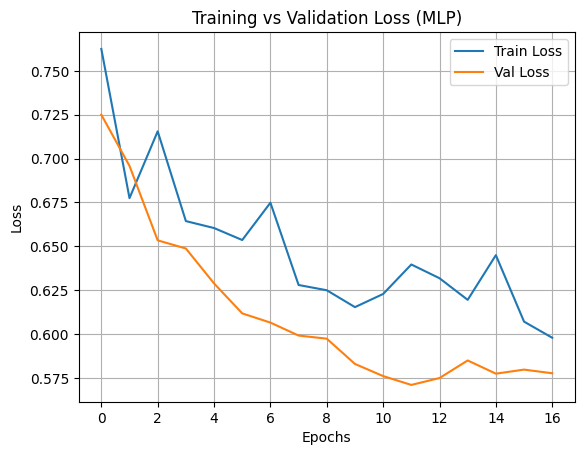

In [83]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (MLP)")
plt.legend()
plt.grid()
plt.show()


In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(name, model, X_test, y_test, mlp=False, threshold=0.6):
    if mlp:
        model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X_test.values, dtype=torch.float32)
            y_proba = torch.sigmoid(model(X_tensor)).numpy().flatten()
        y_pred = (y_proba >= threshold).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred)
    }


In [88]:
all_models = {
    'Logistic Regression': cal_lgr,
    'KNN': cal_knn,
    'SVM': cal_svm,
    'Random Forest': cal_rf,
    'XGBoost': cal_xgb,
    'LightGBM': cal_lgb,
    'MLP (PyTorch)': model  # assuming final MLP loaded & threshold tuned
}

In [89]:
results = []

# scikit-learn models
results.append(evaluate_model("Logistic Regression", cal_lgr, X_test, y_test))
results.append(evaluate_model("KNN", cal_knn, X_test, y_test))
results.append(evaluate_model("SVM", cal_svm, X_test, y_test))
results.append(evaluate_model("Random Forest", cal_rf, X_test, y_test))
results.append(evaluate_model("XGBoost", cal_xgb, X_test, y_test))
results.append(evaluate_model("LightGBM", cal_lgb, X_test, y_test))

results.append(evaluate_model("MLP (PyTorch)", model, X_test, y_test, mlp=True, threshold=0.65))

# Create results DataFrame
df_results = pd.DataFrame(results).sort_values(by='F1-score', ascending=False)
print(df_results)


                 Model  Accuracy  Precision    Recall  F1-score
3        Random Forest  0.918033   0.896552  0.928571  0.912281
4              XGBoost  0.885246   0.818182  0.964286  0.885246
1                  KNN  0.885246   0.838710  0.928571  0.881356
5             LightGBM  0.885246   0.838710  0.928571  0.881356
2                  SVM  0.836066   0.781250  0.892857  0.833333
6        MLP (PyTorch)  0.721311   0.761905  0.571429  0.653061
0  Logistic Regression  0.540984   0.000000  0.000000  0.000000


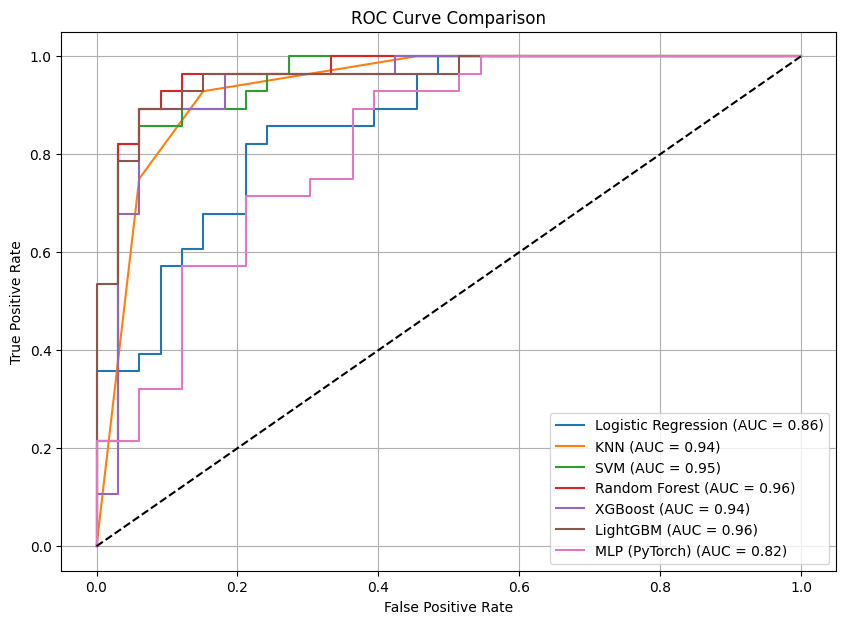

In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for name, m in all_models.items():
    if hasattr(m, "predict_proba"):
        y_scores = m.predict_proba(X_test)[:, 1]
    else:  # MLP case
        with torch.no_grad():
            y_scores = torch.sigmoid(m(torch.tensor(X_test.values, dtype=torch.float32))).numpy().flatten()
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

<h2>Ensemble Voting Classifier</h2>

**앙상블 보팅 분류기(Ensemble Voting Classifier)**는 여러 개의 서로 다른 머신러닝 모델을 결합하여 더 강력하고 안정적인 예측을 만드는 기법입니다.

**핵심 개념:**
- **앙상블 학습**: "집단 지성"의 원리를 활용하여 개별 모델보다 더 나은 성능 달성
- **다양성**: 서로 다른 알고리즘들이 서로 다른 관점에서 데이터를 학습
- **투표 방식**: 여러 모델의 예측을 종합하여 최종 결정

**보팅 방식:**
1. **하드 보팅(Hard Voting)**:
   - 각 모델의 예측 클래스를 수집
   - 다수결 원칙으로 최종 클래스 결정
   - 예: 5개 모델 중 3개가 "심장병 있음"이면 최종 결과도 "심장병 있음"

2. **소프트 보팅(Soft Voting)**:
   - 각 모델의 확률값을 평균화
   - 더 정확한 예측 가능 (확률 정보 활용)
   - 일반적으로 하드 보팅보다 성능이 우수

**장점:**
- **성능 향상**: 개별 모델의 오차를 상호 보완
- **과적합 감소**: 다양한 모델의 조합으로 일반화 능력 향상
- **안정성**: 개별 모델의 편향이나 분산을 줄임

**선택된 모델:**
- **Random Forest**: 트리 기반 앙상블, 안정적인 성능
- **XGBoost**: 그래디언트 부스팅, 높은 정확도
- **Logistic Regression**: 선형 모델, 해석 가능성

이 조합은 서로 다른 학습 방식을 가진 모델들로 구성되어 심장병 예측에서 더욱 신뢰할 수 있는 결과를 제공할 것입니다.

In [91]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[
    ('rf', cal_rf),
    ('xgb', cal_xgb),
    ('lr', cal_lgr)
], voting='soft')

voting.fit(X_train, y_train)
y_pred = voting.predict(X_test)

print("Voting Classifier Performance:")
print(classification_report(y_test, y_pred))



Voting Classifier Performance:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92        33
           1       0.87      0.96      0.92        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [92]:
results = []

results.append(evaluate_model("Logistic Regression", cal_lgr, X_test, y_test))
results.append(evaluate_model("KNN", cal_knn, X_test, y_test))
results.append(evaluate_model("SVM", cal_svm, X_test, y_test))
results.append(evaluate_model("Random Forest", cal_rf, X_test, y_test))
results.append(evaluate_model("XGBoost", cal_xgb, X_test, y_test))
results.append(evaluate_model("LightGBM", cal_lgb, X_test, y_test))
results.append(evaluate_model("Ensemble", voting, X_test, y_test))

results.append(evaluate_model("MLP (PyTorch)", model, X_test, y_test, mlp=True, threshold=0.65))

df_results = pd.DataFrame(results).sort_values(by='F1-score', ascending=False)
print(df_results)


                 Model  Accuracy  Precision    Recall  F1-score
6             Ensemble  0.918033   0.870968  0.964286  0.915254
3        Random Forest  0.918033   0.896552  0.928571  0.912281
4              XGBoost  0.885246   0.818182  0.964286  0.885246
1                  KNN  0.885246   0.838710  0.928571  0.881356
5             LightGBM  0.885246   0.838710  0.928571  0.881356
2                  SVM  0.836066   0.781250  0.892857  0.833333
7        MLP (PyTorch)  0.721311   0.761905  0.571429  0.653061
0  Logistic Regression  0.540984   0.000000  0.000000  0.000000
